In [13]:
%matplotlib widget
import torch

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance, plot_gradients, InteractiveSpikePlot

In [14]:
torch.manual_seed(42)
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [15]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=1000,
    train=True,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=1000,
    train=False,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

Test Accuracy before training is: 0.05560661764705882


Epoch 0:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 0, Iteration 0 — Loss: 3.09, Acc: 3.91%
Epoch 0, Iteration 25 — Loss: 3.08, Acc: 3.12%
Epoch 0, Iteration 50 — Loss: 2.99, Acc: 6.25%


Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1, Iteration 0 — Loss: 2.98, Acc: 9.38%
Epoch 1, Iteration 25 — Loss: 3.14, Acc: 4.69%
Epoch 1, Iteration 50 — Loss: 3.04, Acc: 3.91%


...

Epoch 7, Iteration 0 — Loss: 2.90, Acc: 4.69%
Epoch 7, Iteration 25 — Loss: 2.97, Acc: 11.72%
Epoch 7, Iteration 50 — Loss: 3.01, Acc: 6.25%


Epoch 8:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 8, Iteration 0 — Loss: 2.94, Acc: 8.59%
Epoch 8, Iteration 25 — Loss: 2.84, Acc: 12.50%
Epoch 8, Iteration 50 — Loss: 2.92, Acc: 10.94%


Epoch 9:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9, Iteration 0 — Loss: 2.93, Acc: 14.06%
Epoch 9, Iteration 25 — Loss: 2.90, Acc: 7.81%
Epoch 9, Iteration 50 — Loss: 2.91, Acc: 13.28%
Test Accuracy after training is: 0.09604779411764706


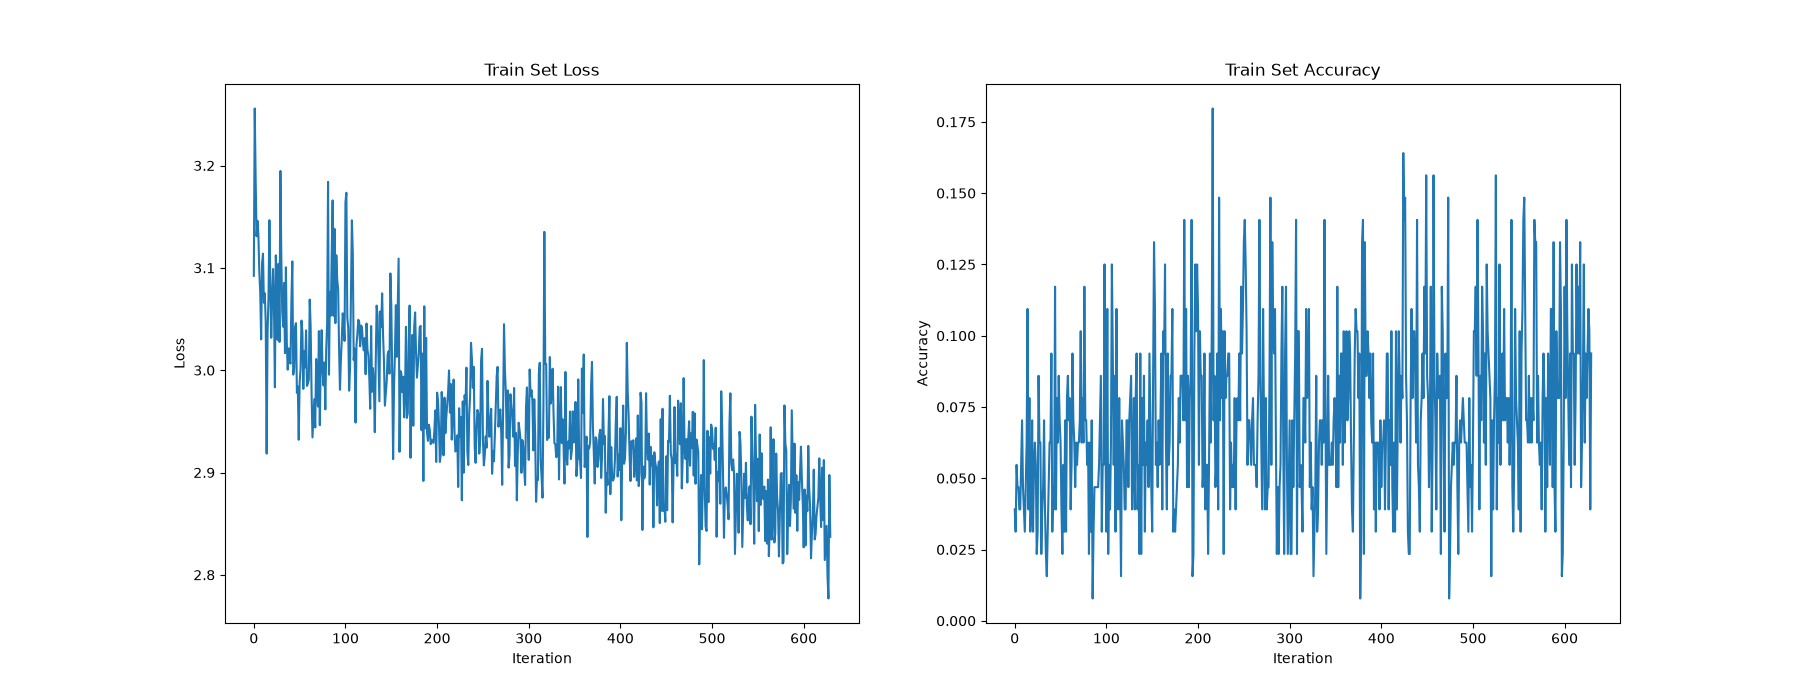

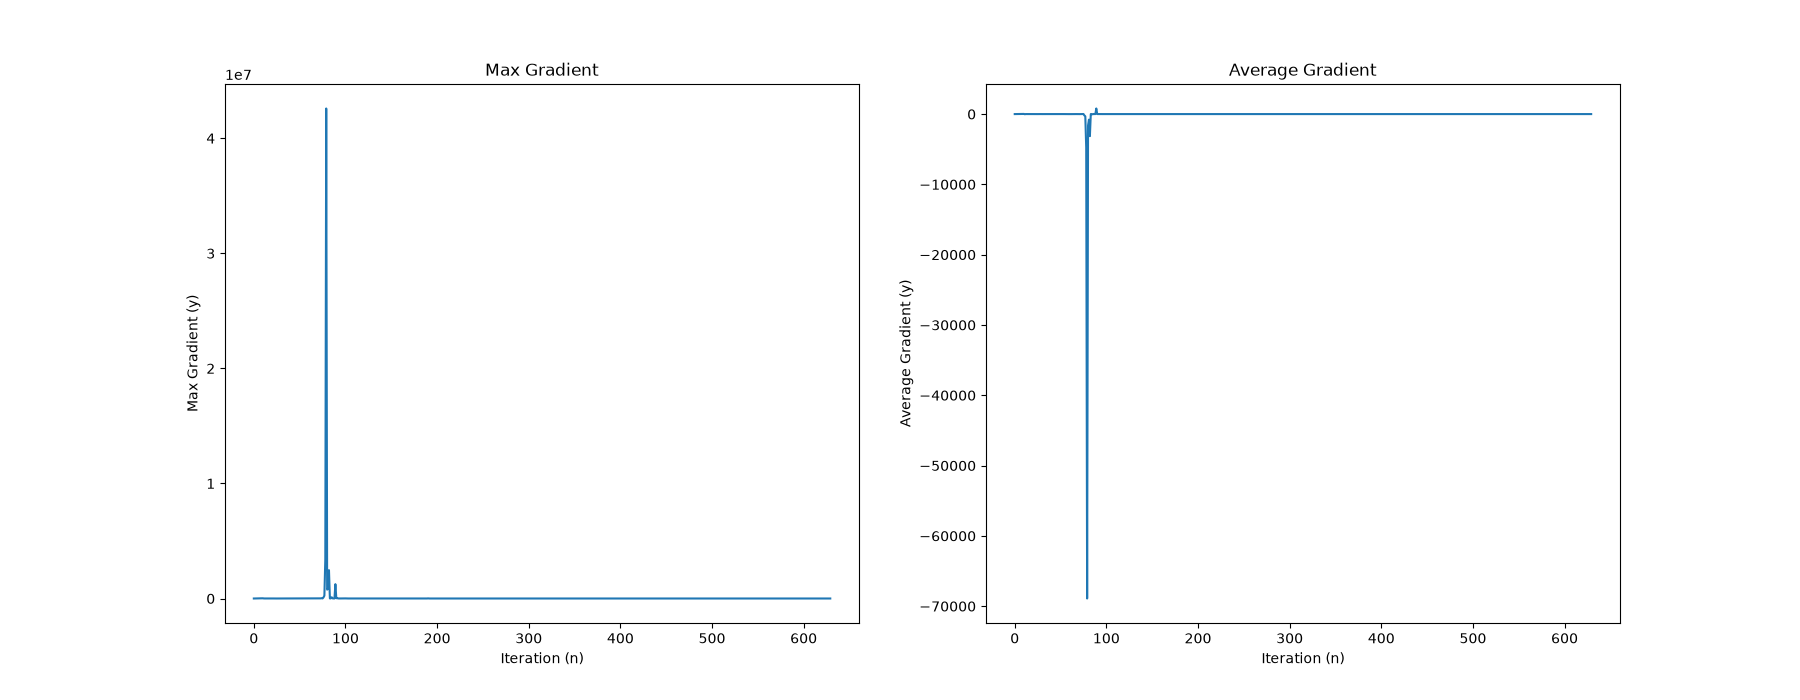

In [17]:
# With cumsum loss now
from torch import Tensor
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import torch.nn.functional as F

from matplotlib import pyplot as plt

def compute_loss(mem_rec: Tensor, targets: Tensor) -> Tensor:
    probs = F.softmax(mem_rec, dim=-1)
    log_probs = torch.log(probs.mean(dim=0) + 1e-8) # to avoid log(0)
    return F.nll_loss(log_probs, targets)

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, eps=1e-6, betas=(0.9, 0.99))

    loss_hist, acc_hist, spike_hist = [], [], []
    net.train()
    max_grad_rec = []
    avg_grad_rec = []

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device).long()
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets)

            grads = {name: p.grad.detach().clone()
                for name, p in net.named_parameters() if p.grad is not None}
            if len(grads) > 0:
                flat_grads = torch.cat([t.flatten() for t in grads.values()])
                max_grad_rec.append(flat_grads.max(dim=0).values.cpu().numpy())
                avg_grad_rec.append(flat_grads.mean(dim=0).cpu().numpy())
            else:
                max_grad_rec.append(0)
                avg_grad_rec.append(0)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist, spike_hist, max_grad_rec, avg_grad_rec


ns_hidden=[256, 256]
layers = [input_dim] + ns_hidden

net = models.StandardSRNN(
    forward_matrices=[torch.ones(n_in, n_out) for n_in, n_out in zip(layers[:-1], layers[1:])],
    recurrent_matrices=[torch.ones(n, n) for n in ns_hidden],
    n_classes=len(classes),
    device=device,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net, loss_hist, acc_hist, spike_hist, max_grad_rec, avg_grad_rec = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-3,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)
plot_gradients(max_grad_rec, avg_grad_rec)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

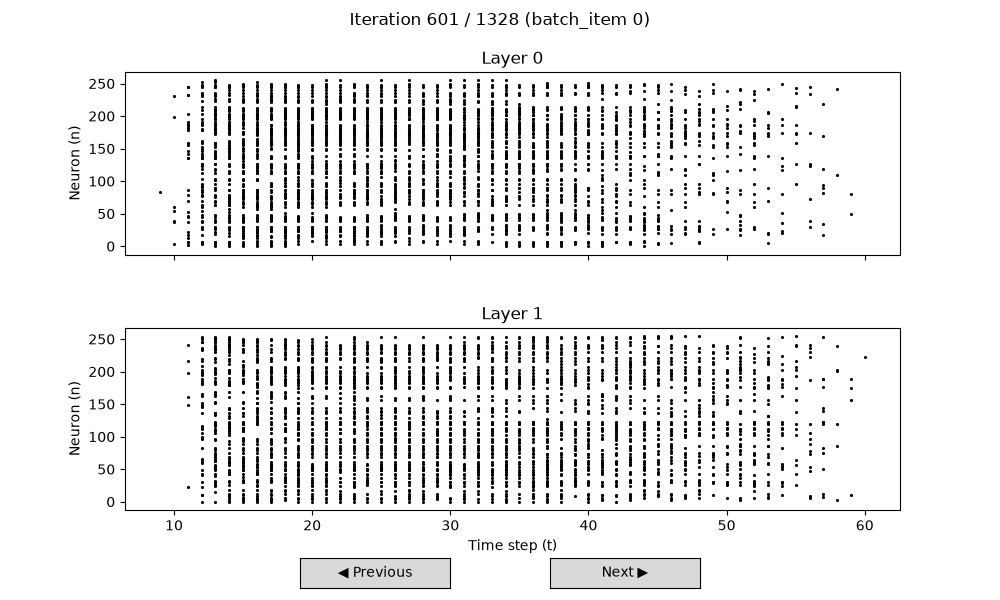

IndexError: list index out of range

IndexError: list index out of range

RuntimeError: Another Axes already grabs mouse input

IndexError: list index out of range

IndexError: list index out of range

In [12]:
isp = InteractiveSpikePlot(
    recorder=net.get_recorder(), 
    iteration_i_start=600, 
    batch_item_i=0,
)
isp.draw()
plt.show()